In [ ]:
import duckdb
from networks.cnn_shallow import CNNModel


con = duckdb.connect('../capillary.db')
df = con.execute(""" 
                 SELECT row_id, value,fractions, boundaries,albumin,antitrypsin,orosomukoid,haptoglobin,crp,igg,iga,igm, label, set, interpretation
                 FROM protein_data
                 WHERE value IS NOT NULL
                 AND observation_nr = 1
                 AND analysis IS NOT NULL
                 AND protein_value IS NOT NULL
                 """).df()
con.close()


train_rows = df[df['set'] == 'train']
val_rows   = df[df['set'] == 'val']
test_rows  = df[df['set'] == 'test']

drop_indices = train_rows[train_rows['label'] == 0].sample(frac=0.7).index

train_rows = train_rows.drop(drop_indices)
train_rows = train_rows[train_rows['label'].isin([0,1])]
val_rows = val_rows[val_rows['label'].isin([0,1])]

print(f"Antal utan m-komponent i träningsdatan: {len(train_rows[train_rows['label'] == 0])}")
print(f"Antal med m-komponent i träningsdatan: {len(train_rows[train_rows['label'] == 1])}")

CNN = CNNModel()
cnn_train_dl, cnn_val_dl, _ = CNN.build_dataloaders(train_rows, val_rows, val_rows)
CNN.reset_weights()
CNN.retrain(cnn_train_dl,cnn_val_dl,patience=15)

con = duckdb.connect('../capillary.db')
df = con.execute(""" 
                 SELECT row_id, value,fractions, boundaries,albumin,antitrypsin,orosomukoid,haptoglobin,crp,igg,iga,igm, label, set, interpretation
                 FROM protein_data
                 WHERE value IS NOT NULL
                 AND observation_nr = 1
                 AND analysis IS NOT NULL
                 AND protein_value IS NOT NULL
                 """).df()
con.close()


k_fold_rows = df[df['set'].isin(['train','val']) ].copy()
k_fold_rows = k_fold_rows[k_fold_rows['label'].isin([0,1])]
drop_indices = k_fold_rows[k_fold_rows['label'] == 0].sample(frac=0.7).index
k_fold_rows = k_fold_rows.drop(drop_indices)
print(f"Totalt antal utan m-komponent i K-fold poolen: {len(k_fold_rows[k_fold_rows['label'] == 0])}")
print(f"Totalt antal med m-komponent i K-fold poolen: {len(k_fold_rows[k_fold_rows['label'] == 1])}")

test_rows  = df[df['set'] == 'test']


CNN = CNNModel()
CNN.retrain_with_k_fold(k_fold_rows)

Antal utan m-komponent i träningsdatan: 17903
Antal med m-komponent i träningsdatan: 2553
Total parameters: 314,674
  -> ny bästa modell sparad till ../models/cnn_shallow.pth
Epoch   0 | train: 0.5739 | val: 0.4004 | acc: 94.86% | AUC: 0.889  | LR: 0.001
  -> ny bästa modell sparad till ../models/cnn_shallow.pth
Epoch   1 | train: 0.4035 | val: 0.3416 | acc: 90.99% | AUC: 0.951  | LR: 0.001
  -> ny bästa modell sparad till ../models/cnn_shallow.pth
Epoch   2 | train: 0.3272 | val: 0.2861 | acc: 92.21% | AUC: 0.969  | LR: 0.001
  -> ny bästa modell sparad till ../models/cnn_shallow.pth
Epoch   3 | train: 0.2785 | val: 0.2029 | acc: 96.11% | AUC: 0.975  | LR: 0.001
  -> ny bästa modell sparad till ../models/cnn_shallow.pth
Epoch   4 | train: 0.2463 | val: 0.1789 | acc: 96.56% | AUC: 0.984  | LR: 0.001
  -> ny bästa modell sparad till ../models/cnn_shallow.pth
Epoch   5 | train: 0.2164 | val: 0.1298 | acc: 97.96% | AUC: 0.989  | LR: 0.001
Epoch   6 | train: 0.2217 | val: 0.1666 | acc: 96.

,fold,train_loss,val_loss,val_accuracy,val_auc,val_spec,val_sens,tn,fp,fn,tp
0,1,0.036029,0.142873,96.425255,0.990477,0.969214,0.929630,1826,58,19,251
1,2,0.071362,0.124129,96.332405,0.989530,0.964968,0.951852,1818,66,13,257
2,3,0.067505,0.165644,97.352531,0.983796,0.984076,0.899628,1854,30,27,242
3,4,0.093775,0.158436,96.234310,0.982544,0.967588,0.925651,1821,61,20,249
4,5,0.056296,0.143225,96.793680,0.989712,0.973447,0.929368,1833,50,19,250
5,6,0.082423,0.139707,97.168059,0.986897,0.979841,0.914498,1847,38,23,246
6,7,0.099678,0.132311,96.332405,0.987353,0.966578,0.940520,1822,63,16,253
7,8,0.075451,0.197620,95.821727,0.978968,0.967109,0.895911,1823,62,28,241
8,9,0.088052,0.273959,96.982358,0.972846,0.980902,0.892193,1849,36,29,240
9,10,0.097244,0.120290,96.098467,0.988437,0.964968,0.933086,1818,66,18,251


In [2]:
import duckdb
from functions.evaluation import evaluate
from networks.cnn_deep import CNNModel
from networks.cnn_network import build_dataloaders


con = duckdb.connect('../capillary.db')
df = con.execute(""" 
                 SELECT row_id, value,fractions, boundaries,albumin,antitrypsin,orosomukoid,haptoglobin,crp,igg,iga,igm, label, set, interpretation
                 FROM protein_data
                 WHERE value IS NOT NULL
                 AND observation_nr = 1
                 AND analysis IS NOT NULL
                 AND protein_value IS NOT NULL
                 """).df()
con.close()


train_rows = df[df['set'] == 'train']
val_rows   = df[df['set'] == 'val']
test_rows  = df[df['set'] == 'test']

drop_indices = train_rows[train_rows['label'] == 0].sample(frac=0.7).index

train_rows = train_rows.drop(drop_indices)
train_rows = train_rows[train_rows['label'].isin([0,1])]
val_rows = val_rows[val_rows['label'].isin([0,1])]

print(f"Antal utan m-komponent i träningsdatan: {len(train_rows[train_rows['label'] == 0])}")
print(f"Antal med m-komponent i träningsdatan: {len(train_rows[train_rows['label'] == 1])}")

CNN = CNNModel()
cnn_train_dl, cnn_val_dl, _ = build_dataloaders(train_rows, val_rows, val_rows)
CNN.reset_weights()
CNN.retrain(cnn_train_dl,cnn_val_dl,patience=15)

con = duckdb.connect('../capillary.db')
df = con.execute(""" 
                 SELECT row_id, value,fractions, boundaries,albumin,antitrypsin,orosomukoid,haptoglobin,crp,igg,iga,igm, label, set, interpretation
                 FROM protein_data
                 WHERE value IS NOT NULL
                 AND observation_nr = 1
                 AND analysis IS NOT NULL
                 AND protein_value IS NOT NULL
                 """).df()
con.close()


k_fold_rows = df[df['set'].isin(['train','val']) ].copy()
k_fold_rows = k_fold_rows[k_fold_rows['label'].isin([0,1])]
drop_indices = k_fold_rows[k_fold_rows['label'] == 0].sample(frac=0.7).index
k_fold_rows = k_fold_rows.drop(drop_indices)
print(f"Totalt antal utan m-komponent i K-fold poolen: {len(k_fold_rows[k_fold_rows['label'] == 0])}")
print(f"Totalt antal med m-komponent i K-fold poolen: {len(k_fold_rows[k_fold_rows['label'] == 1])}")

test_rows  = df[df['set'] == 'test']


CNN = CNNModel()
CNN.retrain_with_k_fold(k_fold_rows)

Antal utan m-komponent i träningsdatan: 17903
Antal med m-komponent i träningsdatan: 2553
Total parameters: 320,194
  -> ny bästa modell sparad till ../models/cnn_deep.pth
Epoch   0 | train: 0.4786 | val: 0.2611 | acc: 98.17% | AUC: 0.970  | LR: 0.001
  -> ny bästa modell sparad till ../models/cnn_deep.pth
Epoch   1 | train: 0.2140 | val: 0.1876 | acc: 94.86% | AUC: 0.994  | LR: 0.001
  -> ny bästa modell sparad till ../models/cnn_deep.pth
Epoch   2 | train: 0.1651 | val: 0.1344 | acc: 96.50% | AUC: 0.996  | LR: 0.001
Epoch   3 | train: 0.1342 | val: 0.0840 | acc: 97.84% | AUC: 0.995  | LR: 0.001
  -> ny bästa modell sparad till ../models/cnn_deep.pth
Epoch   4 | train: 0.1238 | val: 0.0513 | acc: 98.97% | AUC: 0.996  | LR: 0.001
  -> ny bästa modell sparad till ../models/cnn_deep.pth
Epoch   5 | train: 0.1124 | val: 0.0602 | acc: 98.75% | AUC: 0.998  | LR: 0.001
Epoch   6 | train: 0.1026 | val: 0.1039 | acc: 96.93% | AUC: 0.997  | LR: 0.001
Epoch   7 | train: 0.0981 | val: 0.0657 | ac

,fold,train_loss,val_loss,val_accuracy,val_auc,val_spec,val_sens,tn,fp,fn,tp
0,1,0.059638,0.184787,97.491872,0.991202,0.987792,0.884758,1861,23,31,238
1,2,0.052757,0.093416,96.745700,0.993665,0.968119,0.962825,1822,60,10,259
2,3,0.111374,0.105074,96.048350,0.993570,0.962274,0.947955,1811,71,14,255
3,4,0.033706,0.118083,97.307335,0.991116,0.978780,0.933086,1845,40,18,251
4,5,0.037678,0.233784,97.632312,0.987775,0.992573,0.862454,1871,14,37,232
5,6,0.092830,0.121705,97.307335,0.988684,0.978249,0.936803,1844,41,17,252
6,7,0.101043,0.151971,96.191361,0.988982,0.967091,0.925651,1822,62,20,249
7,8,0.073195,0.100407,97.120297,0.995132,0.975053,0.944238,1837,47,15,254
8,9,0.066773,0.119772,96.378830,0.991749,0.967091,0.940741,1822,62,16,254
9,10,0.055237,0.093284,98.421541,0.995455,0.989384,0.948148,1864,20,14,256


In [3]:
import duckdb
from functions.evaluation import evaluate
from networks.cnn_deeper import CNNModel
from networks.cnn_network import build_dataloaders


con = duckdb.connect('../capillary.db')
df = con.execute(""" 
                 SELECT row_id, value,fractions, boundaries,albumin,antitrypsin,orosomukoid,haptoglobin,crp,igg,iga,igm, label, set, interpretation
                 FROM protein_data
                 WHERE value IS NOT NULL
                 AND observation_nr = 1
                 AND analysis IS NOT NULL
                 AND protein_value IS NOT NULL
                 """).df()
con.close()


train_rows = df[df['set'] == 'train']
val_rows   = df[df['set'] == 'val']
test_rows  = df[df['set'] == 'test']

drop_indices = train_rows[train_rows['label'] == 0].sample(frac=0.7).index

train_rows = train_rows.drop(drop_indices)
train_rows = train_rows[train_rows['label'].isin([0,1])]
val_rows = val_rows[val_rows['label'].isin([0,1])]

print(f"Antal utan m-komponent i träningsdatan: {len(train_rows[train_rows['label'] == 0])}")
print(f"Antal med m-komponent i träningsdatan: {len(train_rows[train_rows['label'] == 1])}")

CNN = CNNModel()
cnn_train_dl, cnn_val_dl, _ = build_dataloaders(train_rows, val_rows, val_rows)
CNN.reset_weights()
CNN.retrain(cnn_train_dl,cnn_val_dl,patience=15)

con = duckdb.connect('../capillary.db')
df = con.execute(""" 
                 SELECT row_id, value,fractions, boundaries,albumin,antitrypsin,orosomukoid,haptoglobin,crp,igg,iga,igm, label, set, interpretation
                 FROM protein_data
                 WHERE value IS NOT NULL
                 AND observation_nr = 1
                 AND analysis IS NOT NULL
                 AND protein_value IS NOT NULL
                 """).df()
con.close()


k_fold_rows = df[df['set'].isin(['train','val']) ].copy()
k_fold_rows = k_fold_rows[k_fold_rows['label'].isin([0,1])]
drop_indices = k_fold_rows[k_fold_rows['label'] == 0].sample(frac=0.7).index
k_fold_rows = k_fold_rows.drop(drop_indices)
print(f"Totalt antal utan m-komponent i K-fold poolen: {len(k_fold_rows[k_fold_rows['label'] == 0])}")
print(f"Totalt antal med m-komponent i K-fold poolen: {len(k_fold_rows[k_fold_rows['label'] == 1])}")

test_rows  = df[df['set'] == 'test']


CNN = CNNModel()
CNN.retrain_with_k_fold(k_fold_rows)

Antal utan m-komponent i träningsdatan: 17903
Antal med m-komponent i träningsdatan: 2553
Total parameters: 324,898
  -> ny bästa modell sparad till ../models/cnn_deeper.pth
Epoch   0 | train: 0.5000 | val: 0.2996 | acc: 93.58% | AUC: 0.904  | LR: 0.001
  -> ny bästa modell sparad till ../models/cnn_deeper.pth
Epoch   1 | train: 0.2741 | val: 0.1187 | acc: 98.14% | AUC: 0.992  | LR: 0.001
  -> ny bästa modell sparad till ../models/cnn_deeper.pth
Epoch   2 | train: 0.1804 | val: 0.1377 | acc: 95.92% | AUC: 0.995  | LR: 0.001
  -> ny bästa modell sparad till ../models/cnn_deeper.pth
Epoch   3 | train: 0.1530 | val: 0.0825 | acc: 97.84% | AUC: 0.996  | LR: 0.001
Epoch   4 | train: 0.1358 | val: 0.1499 | acc: 95.31% | AUC: 0.995  | LR: 0.001
Epoch   5 | train: 0.1146 | val: 0.0629 | acc: 98.75% | AUC: 0.996  | LR: 0.001
  -> ny bästa modell sparad till ../models/cnn_deeper.pth
Epoch   6 | train: 0.1130 | val: 0.0734 | acc: 98.05% | AUC: 0.996  | LR: 0.001
Epoch   7 | train: 0.1036 | val: 0

,fold,train_loss,val_loss,val_accuracy,val_auc,val_spec,val_sens,tn,fp,fn,tp
0,1,0.079093,0.125409,95.123084,0.993240,0.946362,0.985185,1782,101,4,266
1,2,0.075522,0.089224,97.538319,0.992210,0.979288,0.948148,1844,39,14,256
2,3,0.084683,0.144704,97.818013,0.988934,0.988859,0.903346,1864,21,26,243
3,4,0.086489,0.129664,98.141264,0.990484,0.986192,0.947955,1857,26,14,255
4,5,0.071107,0.092026,95.914578,0.995087,0.958090,0.966543,1806,79,9,260
5,6,0.088539,0.094557,96.609382,0.993964,0.966030,0.966543,1820,64,9,260
6,7,0.070159,0.096156,96.239554,0.992975,0.963395,0.955390,1816,69,12,257
7,8,0.034085,0.206832,97.864438,0.991597,0.988859,0.907063,1864,21,25,244
8,9,0.092711,0.151197,97.493036,0.987587,0.983024,0.918216,1853,32,22,247
9,10,0.135504,0.162608,94.240595,0.990653,0.937898,0.973978,1767,117,7,262


In [4]:
import duckdb
from functions.evaluation import evaluate
from networks.cnn_deepest import CNNModel
from networks.cnn_network import build_dataloaders


con = duckdb.connect('../capillary.db')
df = con.execute(""" 
                 SELECT row_id, value,fractions, boundaries,albumin,antitrypsin,orosomukoid,haptoglobin,crp,igg,iga,igm, label, set, interpretation
                 FROM protein_data
                 WHERE value IS NOT NULL
                 AND observation_nr = 1
                 AND analysis IS NOT NULL
                 AND protein_value IS NOT NULL
                 """).df()
con.close()


train_rows = df[df['set'] == 'train']
val_rows   = df[df['set'] == 'val']
test_rows  = df[df['set'] == 'test']

drop_indices = train_rows[train_rows['label'] == 0].sample(frac=0.7).index

train_rows = train_rows.drop(drop_indices)
train_rows = train_rows[train_rows['label'].isin([0,1])]
val_rows = val_rows[val_rows['label'].isin([0,1])]

print(f"Antal utan m-komponent i träningsdatan: {len(train_rows[train_rows['label'] == 0])}")
print(f"Antal med m-komponent i träningsdatan: {len(train_rows[train_rows['label'] == 1])}")

CNN = CNNModel()
cnn_train_dl, cnn_val_dl, _ = build_dataloaders(train_rows, val_rows, val_rows)
CNN.reset_weights()
CNN.retrain(cnn_train_dl,cnn_val_dl,patience=15)

con = duckdb.connect('../capillary.db')
df = con.execute(""" 
                 SELECT row_id, value,fractions, boundaries,albumin,antitrypsin,orosomukoid,haptoglobin,crp,igg,iga,igm, label, set, interpretation
                 FROM protein_data
                 WHERE value IS NOT NULL
                 AND observation_nr = 1
                 AND analysis IS NOT NULL
                 AND protein_value IS NOT NULL
                 """).df()
con.close()


k_fold_rows = df[df['set'].isin(['train','val']) ].copy()
k_fold_rows = k_fold_rows[k_fold_rows['label'].isin([0,1])]
drop_indices = k_fold_rows[k_fold_rows['label'] == 0].sample(frac=0.7).index
k_fold_rows = k_fold_rows.drop(drop_indices)
print(f"Totalt antal utan m-komponent i K-fold poolen: {len(k_fold_rows[k_fold_rows['label'] == 0])}")
print(f"Totalt antal med m-komponent i K-fold poolen: {len(k_fold_rows[k_fold_rows['label'] == 1])}")

test_rows  = df[df['set'] == 'test']


CNN = CNNModel()
CNN.retrain_with_k_fold(k_fold_rows)

Antal utan m-komponent i träningsdatan: 17903
Antal med m-komponent i träningsdatan: 2553
Total parameters: 330,626
  -> ny bästa modell sparad till ../models/cnn_deepest.pth
Epoch   0 | train: 0.5010 | val: 0.3310 | acc: 97.44% | AUC: 0.929  | LR: 0.001
  -> ny bästa modell sparad till ../models/cnn_deepest.pth
Epoch   1 | train: 0.2413 | val: 0.0962 | acc: 98.72% | AUC: 0.992  | LR: 0.001
  -> ny bästa modell sparad till ../models/cnn_deepest.pth
Epoch   2 | train: 0.1659 | val: 0.1046 | acc: 97.32% | AUC: 0.997  | LR: 0.001
Epoch   3 | train: 0.1415 | val: 0.0856 | acc: 97.63% | AUC: 0.996  | LR: 0.001
Epoch   4 | train: 0.1311 | val: 0.1190 | acc: 96.05% | AUC: 0.994  | LR: 0.001
Epoch   5 | train: 0.1168 | val: 0.0784 | acc: 97.38% | AUC: 0.995  | LR: 0.001
Epoch   6 | train: 0.1103 | val: 0.0663 | acc: 98.30% | AUC: 0.994  | LR: 0.001
Epoch   7 | train: 0.1018 | val: 0.0996 | acc: 96.65% | AUC: 0.995  | LR: 0.001
Epoch   8 | train: 0.0924 | val: 0.0863 | acc: 97.29% | AUC: 0.995 

,fold,train_loss,val_loss,val_accuracy,val_auc,val_spec,val_sens,tn,fp,fn,tp
0,1,0.053021,0.118101,97.957289,0.993869,0.987798,0.921933,1862,23,21,248
1,2,0.059175,0.135712,94.893222,0.992588,0.949072,0.947955,1789,96,14,255
2,3,0.061609,0.096095,97.769517,0.993142,0.982475,0.944238,1850,33,15,254
3,4,0.090991,0.109103,96.423595,0.991799,0.966030,0.951673,1820,64,13,256
4,5,0.051632,0.165063,97.493036,0.986270,0.983024,0.918216,1853,32,22,247
5,6,0.116540,0.115304,95.819786,0.993137,0.957006,0.966543,1803,81,9,260
6,7,0.068987,0.184492,97.443050,0.987710,0.981934,0.921933,1848,34,21,248
7,8,0.076892,0.118811,96.888063,0.994400,0.969214,0.966543,1826,58,9,260
8,9,0.073927,0.148657,97.770553,0.993812,0.985661,0.922222,1856,27,21,249
9,10,0.049335,0.062096,97.677659,0.997048,0.978226,0.966667,1842,41,9,261


Antal utan m-komponent i testdata: 7056
Antal med m-komponent i testdata: 250
Total parameters: 320,194
[0 1]
[0 1]
              precision    recall  f1-score   support

     Negativ       1.00      0.97      0.98      7056
     Positiv       0.49      0.95      0.65       250

    accuracy                           0.96      7306
   macro avg       0.75      0.96      0.82      7306
weighted avg       0.98      0.96      0.97      7306

[[6812  244]
 [  12  238]]


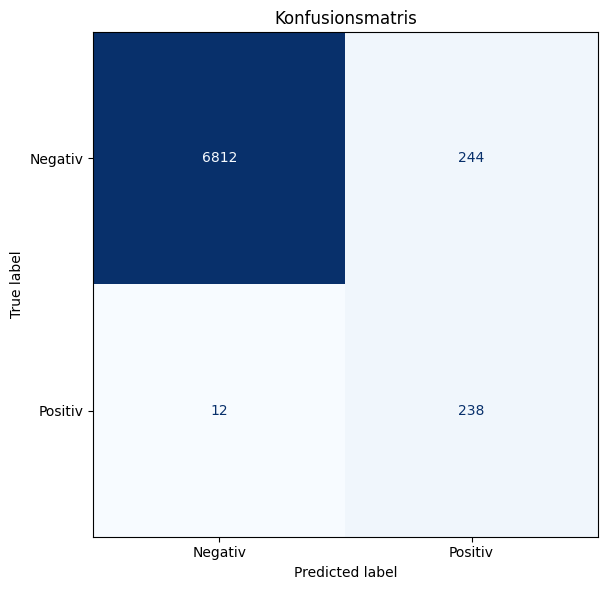

AUC: 0.9902746598639456
Accuracy:  96.50%
FN-rate:   4.80%  (farliga missade fall)
FP-rate:   3.46%  (onödiga larm)
Sensitivitet:   95.20%  (Sannolikhet att upptäcka ett positivt fall)
Specificitet:   96.54%  (Sannolikhet att korrekt klassificera ett negativt fall negativt)
AUC: 0.9903


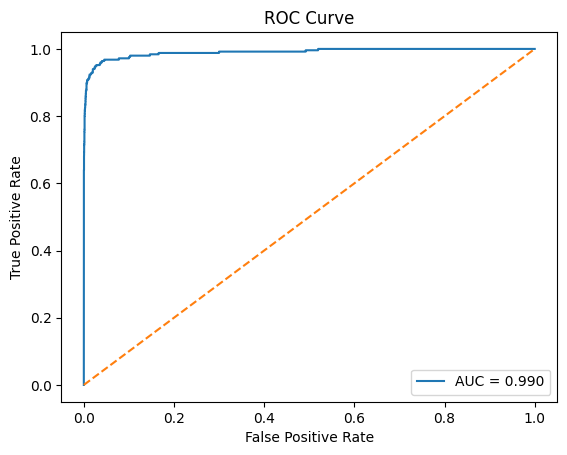

In [7]:
import duckdb
from functions.evaluation import evaluate
from networks.cnn_deep import CNNModel


con = duckdb.connect('../capillary.db')
df = con.execute(""" 
                 SELECT row_id, value,fractions, boundaries,albumin,antitrypsin,orosomukoid,haptoglobin,crp,igg,iga,igm, label, set, interpretation
                 FROM protein_data
                 WHERE observation_nr = 1
                 """).df()
con.close()


train_rows = df[df['set'] == 'train']
val_rows   = df[df['set'] == 'val']
test_rows  = df[df['set'] == 'test']

drop_indices = train_rows[train_rows['label'] == 0].sample(frac=0.7).index

train_rows = train_rows.drop(drop_indices)
train_rows = train_rows[train_rows['label'].isin([0,1])]
val_rows = val_rows[val_rows['label'].isin([0,1])]
test_rows = test_rows[test_rows['label'].isin([0,1])]


print(f"Antal utan m-komponent i testdata: {len(test_rows[test_rows['label'] == 0])}")
print(f"Antal med m-komponent i testdata: {len(test_rows[test_rows['label'] == 1])}")



CNN = CNNModel()
result = CNN.predict(test_rows)
_ = evaluate(result,threshold=0.5)